In [1]:
# !uv run python -m ensurepip --upgrade
# !python -m spacy download en_core_web_sm

In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from single_sentence import (
    check_roles,
    get_linguistic_stats,
    load_experiments_results,
    map_subwords_to_tokens,
    normalize_lengths,
    perform_ttest,
    plot_token_count_distribution,
)
from sklearn.preprocessing import OneHotEncoder

os.makedirs("figures", exist_ok=True)

# Tests and preparation

## Text

In [4]:
t2t_df = load_experiments_results("T2T")

t2t_df["count_explainable_tokens"] = t2t_df["attr_summary"].apply(lambda x: x["count_text_tokens"])
t2t_df["prompt_text_roles"] = t2t_df["conversation"].apply(lambda x: x[1][0]["roles"])
t2t_df["sv"] = t2t_df["conversation"].apply(lambda x: x[1][0]["shap_values"])

t2t_df["raw_model_response"] = t2t_df["conversation"].apply(lambda x: "".join(x[2][0]["content"]))
t2t_df["raw_prompt_text"] = t2t_df["conversation"].apply(lambda x: "".join(x[1][0]["content"]))
t2t_df["raw_prompt_text_tokens"] = t2t_df["conversation"].apply(lambda x: x[1][0]["content"])
if not (
    t2t_df[["prompt_text", "raw_prompt_text"]]
    .apply(lambda row: row["prompt_text"] in row["raw_prompt_text"], axis=1)
    .all()
    .item()
    and t2t_df[["prompt_text_roles", "sv"]].apply(check_roles, axis=1).all()
).item():
    raise RuntimeError("Prompt text or roles check failed.")

In [5]:
t2t_df["attr_summary"][0]

{'abs_sum_text': 0.9999999664723873,
 'abs_sum_audio': 0.0,
 'frac_text': 1.0,
 'frac_audio': 0.0,
 'count_text_tokens': 7,
 'count_audio_segments': 0}

In [6]:
def filter_valid_sv(row: pd.Series) -> pd.Series:
    """Filter valid shap values and tokens."""
    sv = np.asarray(row["sv"])
    valid_mask = ~pd.isna(sv)
    tokens = np.asarray(row["raw_prompt_text_tokens"])[valid_mask]
    return pd.Series(
        {
            "sv": sv[valid_mask],
            "tokens": tokens,
            "inputs": "".join(tokens),
            "row_index": row["row_index"],
            "count_explainable_tokens": len(tokens),
            "neyman_steps": row["neyman_steps"],
            "n_calls": row["n_calls"],
            "runtime_sec": row["runtime_sec"],
            "raw_model_response": row["raw_model_response"],
            "mode": "T2T",
        }
    )


t2t_df = t2t_df.apply(filter_valid_sv, axis=1)

t2t_df.head(5)

,sv,tokens,inputs,row_index,count_explainable_tokens,neyman_steps,n_calls,runtime_sec,raw_model_response,mode
0,"[0.0, 0.1178189367055893, 0.22090736031532288,...","[[', Who, developed, Rec, apt, cha, ']]",['Who developed Recaptcha'],86,7,2,68,48.044328,<|im_start|>assistant\nRecaptcha was developed...,T2T
1,"[0.14533641934394836, 0.12204218655824661, 0.2...","[[', Who, invented, fantasy, sports, ']]",['Who invented fantasy sports'],25,6,2,18,25.328912,<|im_start|>assistant\nThe concept of fantasy ...,T2T
2,"[0.08296709507703781, 0.08216387033462524, 0.1...","[[', When, was, the, Aten, eo, de, Manila...",['When was the Ateneo de Manila University fou...,55,11,2,240,107.440828,<|im_start|>assistant\nThe Ateneo de Manila Un...,T2T
3,"[0.13821464776992798, 0.2678728699684143, 0.16...","[[', Who, discovered, infrared, light, ']]",['Who discovered infrared light'],49,6,2,18,26.648144,<|im_start|>assistant\nThe discovery of infrar...,T2T
4,"[0.05872317776083946, 0.278507262468338, 0.098...","[[', How, does, metabolism, work, ']]",['How does metabolism work'],39,6,2,20,26.084987,<|im_start|>assistant\nMetabolism is the set o...,T2T


## Audio

In [7]:
sm2t_df = load_experiments_results("SM2T")
sm2t_df["mode"] = "SM2T"

sm2s_df = load_experiments_results("SM2S")
sm2s_df["mode"] = "SM2S"

sf2t_df = load_experiments_results("SF2T")
sf2t_df["mode"] = "SF2T"

sf2s_df = load_experiments_results("SF2S")
sf2s_df["mode"] = "SF2S"

audio_df = pd.concat([sm2t_df, sm2s_df, sf2t_df, sf2s_df], ignore_index=True)

In [8]:
audio_df["count_explainable_tokens"] = audio_df["audio_segments"].apply(lambda x: len(x["2"]) if "2" in x else None)
audio_df["inputs"] = audio_df["audio_segments"].apply(
    lambda x: " ".join(y["token"] for y in x["2"]) if "2" in x else None
)
audio_df["tokens"] = audio_df["audio_segments"].apply(lambda x: [y["token"] for y in x["2"]] if "2" in x else None)
audio_df["sv"] = audio_df["audio_segments"].apply(lambda x: [y["shap_value"] for y in x["2"]] if "2" in x else None)
audio_df["raw_model_response"] = audio_df["conversation"].apply(lambda x: "".join(x[2][0]["content"]))

if (audio_df["count_explainable_tokens"] != audio_df["sv"].apply(len)).any().item():
    raise RuntimeError("Audio token count and shap values length mismatch.")
for c in ["inputs", "tokens", "sv"]:
    if audio_df[c].isna().any().item():
        raise RuntimeError(f"Column {c} contains NaN values.")

audio_df = audio_df[
    [
        "row_index",
        "tokens",
        "sv",
        "inputs",
        "count_explainable_tokens",
        "mode",
        "neyman_steps",
        "n_calls",
        "runtime_sec",
        "raw_model_response",
    ]
]

## Combined

In [9]:
t2t_df["mode"] = "T2T"
df = pd.concat([t2t_df, audio_df], ignore_index=True)

if df.groupby("row_index").agg({"mode": "count"})["mode"].nunique() != 1:
    raise RuntimeError("Missing data.")

# Data preprocessing

## Data distributions

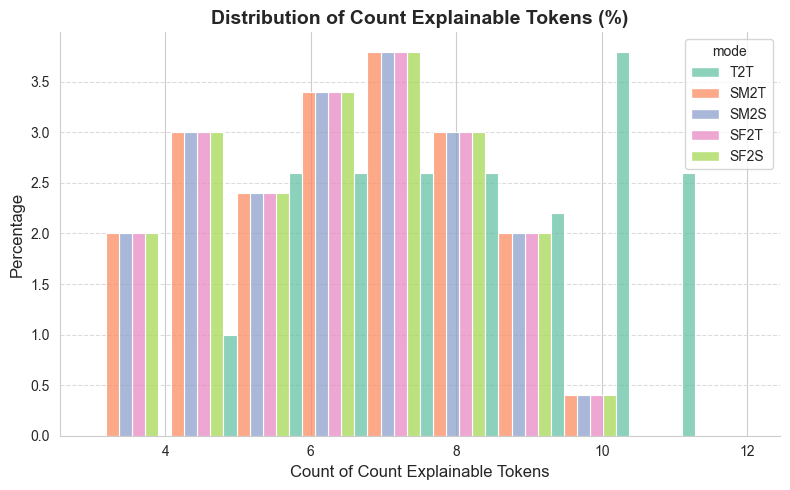

In [10]:
plot_token_count_distribution(df, column="count_explainable_tokens", hue="mode")
plt.savefig("figures/token_count_distribution.png")

In [11]:
neyman_steps_distribution = df.groupby("mode")["neyman_steps"].value_counts(normalize=True)
neyman_steps_distribution.unstack()

neyman_steps,1,2
mode,,
SF2S,0.37,0.63
SF2T,0.37,0.63
SM2S,0.37,0.63
SM2T,0.37,0.63
T2T,0.05,0.95


In [12]:
summary_stats = df.groupby("mode")[["n_calls", "runtime_sec"]].agg(["describe"])
summary_stats.stack(level=0).unstack(level=1)

describe                                                                 \
        count                mean                    std                 min   
      n_calls runtime_sec n_calls runtime_sec    n_calls runtime_sec n_calls   
mode                                                                           
SF2S    100.0       100.0   59.32   66.081696  53.650737   55.220210     6.0   
SF2T    100.0       100.0   59.84   29.841664  54.003127   25.128298     6.0   
SM2S    100.0       100.0   59.42   67.532749  53.608604   56.420089     6.0   
SM2T    100.0       100.0   59.64   29.651513  53.983447   24.478687     6.0   
T2T     100.0       100.0  154.78   91.233753  93.328526   51.997779    16.0   

                                                                              \
                     25%                 50%                 75%               
     runtime_sec n_calls runtime_sec n_calls runtime_sec n_calls runtime_sec   
mode                                                                           
SF2S    4.747431    14.0   16.182326    30.0   43.425780   118.0  123.527769   
SF2T    2.389576    15.5    6.572411    30.0   21.304932   118.5   52.820496   
SM2S    4.848415    15.5   17.166915    30.0   43.832544   120.0  125.736116   
SM2T    2.411437    14.0    6.459457    30.0   21.220281   118.0   50.577328   
T2T     9.457057    66.0   47.814124   157.0   84.335419   240.0  132.516525   

                          
         max              
     n_calls runtime_sec  
mode                      
SF2S   200.0  197.016598  
SF2T   200.0   91.336899  
SM2S   202.0  199.532876  
SM2T   202.0   86.893639  
T2T    300.0  198.424349

In [13]:
for pt, rmr in df[["inputs", "raw_model_response"]].head(5).itertuples(index=False):
    print(pt)
    print("\t- " + rmr.replace("\n", "\\n"))

['Who developed Recaptcha']
	- <|im_start|>assistant\nRecaptcha was developed by **Google**. It was created to help verify that users are human and not bots, which is important for tasks like image recognition, spam filtering, and other security measures.<|im_end|><|im_end|>\n
['Who invented fantasy sports']
	- <|im_start|>assistant\nThe concept of fantasy sports, where fans create teams and compete in leagues, actually has its roots in the world of competitive sports. However, the specific idea of fantasy sports as we know it today was popularized in the United States.\n\nThe idea<|im_end|>\n
['When was the Ateneo de Manila University founded']
	- <|im_start|>assistant\nThe Ateneo de Manila University was founded in 1909.<|im_end|><|im_end|>\n
['Who discovered infrared light']
	- <|im_start|>assistant\nThe discovery of infrared light is credited to **William Herschel**, a German-born British astronomer and physicist. In 1800, Herschel was experimenting with a prism to separate white l

## Enrichment with linguistic features

In [14]:
df["linguistic_stats"] = df["inputs"].apply(get_linguistic_stats)

In [15]:
df["stats_mapping"] = df.apply(
    lambda row: map_subwords_to_tokens(
        row["tokens"],
        [stat["text"] for stat in row["linguistic_stats"]],
    ),
    axis=1,
)

if not (df["stats_mapping"].apply(len) == df["tokens"].apply(len)).all().item():
    raise RuntimeError("Subword to token mapping length mismatch.")

In [16]:
df["stats_matched"] = df.apply(lambda row: [row["linguistic_stats"][i] for i in row["stats_mapping"]], axis=1)
df["deps"] = df["stats_matched"].apply(lambda stats: [stat["dep"] for stat in stats])
df["pos"] = df["stats_matched"].apply(lambda stats: [stat["pos"] for stat in stats])
df["children"] = df["stats_matched"].apply(lambda stats: [stat["children"] for stat in stats])

df.drop(columns=["linguistic_stats", "stats_mapping", "stats_matched"], inplace=True)

In [17]:
exploded_df = (
    df.apply(
        lambda row: [
            {
                "prompt": row["inputs"],
                "row_index": row["row_index"],
                "mode": row["mode"],
                "token": token,
                "sv": sv,
                "dep": dep,
                "pos": pos,
                "children": children,
            }
            for token, sv, dep, pos, children in zip(
                row["tokens"],
                row["sv"],
                row["deps"],
                row["pos"],
                row["children"],
            )
        ],
        axis=1,
    )
    .explode()
    .apply(pd.Series)
    .reset_index(drop=True)
)

In [18]:
exploded_df["dep"].unique()

array(['dep', 'nsubj', 'ROOT', 'dobj', 'punct', 'compound', 'advmod',
       'auxpass', 'det', 'nmod', 'amod', 'aux', 'prep', 'pcomp', 'relcl',
       'xcomp', 'attr', 'pobj', 'nsubjpass', 'dative', 'poss', 'case',
       'mark', 'advcl', 'acl', 'agent', 'acomp', 'ccomp', 'conj', 'cc',
       'appos', 'npadvmod', 'oprd'], dtype=object)

In [19]:
ROOT_DEP = "ROOT"
SV_COL = "sv"

data = [
    # --- Core meaning (highest importance) ---
    {"dep": ROOT_DEP, "importance": 1, "group": "core_structure"},
    {"dep": "nsubj", "importance": 1, "group": "core_structure"},
    {"dep": "nsubjpass", "importance": 1, "group": "core_structure"},
    {"dep": "dobj", "importance": 1, "group": "core_structure"},
    {"dep": "agent", "importance": 1, "group": "core_structure"},
    # --- Clause structure (very important) ---
    {"dep": "ccomp", "importance": 2, "group": "clausal_structure"},
    {"dep": "xcomp", "importance": 2, "group": "clausal_structure"},
    {"dep": "advcl", "importance": 2, "group": "clausal_structure"},
    {"dep": "relcl", "importance": 2, "group": "clausal_structure"},
    {"dep": "acl", "importance": 2, "group": "clausal_structure"},
    {"dep": "pcomp", "importance": 2, "group": "clausal_structure"},
    # --- Nominal / verbal complements ---
    {"dep": "attr", "importance": 3, "group": "arguments"},
    {"dep": "acomp", "importance": 3, "group": "arguments"},
    {"dep": "dative", "importance": 3, "group": "arguments"},
    {"dep": "pobj", "importance": 3, "group": "arguments"},
    {"dep": "oprd", "importance": 3, "group": "arguments"},
    # --- Modifiers (less critical, descriptive) ---
    {"dep": "amod", "importance": 4, "group": "modifiers"},
    {"dep": "advmod", "importance": 4, "group": "modifiers"},
    {"dep": "npadvmod", "importance": 4, "group": "modifiers"},
    {"dep": "nmod", "importance": 4, "group": "modifiers"},
    {"dep": "compound", "importance": 4, "group": "modifiers"},
    {"dep": "poss", "importance": 4, "group": "modifiers"},
    {"dep": "appos", "importance": 4, "group": "modifiers"},
    # --- Coordination / structure helpers ---
    {"dep": "conj", "importance": 4, "group": "coordination"},
    {"dep": "cc", "importance": 5, "group": "coordination"},
    # --- Function / grammar glue (lowest importance) ---
    {"dep": "det", "importance": 5, "group": "function_words"},
    {"dep": "case", "importance": 5, "group": "function_words"},
    {"dep": "aux", "importance": 5, "group": "function_words"},
    {"dep": "auxpass", "importance": 5, "group": "function_words"},
    {"dep": "mark", "importance": 5, "group": "function_words"},
    {"dep": "prep", "importance": 5, "group": "function_words"},
    {"dep": "punct", "importance": 6, "group": "punctuation"},
    # --- Generic / unknown ---
    {"dep": "dep", "importance": 4, "group": "generic"},
]

dep_importance_df = pd.DataFrame(data)
results_df = exploded_df.join(
    dep_importance_df.set_index("dep"),
    on="dep",
    how="left",
)

In [20]:
results_df.head()

,prompt,row_index,mode,token,sv,dep,pos,children,importance,group
0,['Who developed Recaptcha'],86,T2T,[',0.000000,dep,X,0,4,generic
1,['Who developed Recaptcha'],86,T2T,Who,0.117819,nsubj,PRON,0,1,core_structure
2,['Who developed Recaptcha'],86,T2T,developed,0.220907,ROOT,VERB,6,1,core_structure
3,['Who developed Recaptcha'],86,T2T,Rec,0.191570,dobj,PROPN,0,1,core_structure
4,['Who developed Recaptcha'],86,T2T,apt,0.264331,ROOT,VERB,6,1,core_structure


In [21]:
results_df["S2S"] = results_df["mode"].isin(["SM2S", "SF2S"])
results_df["S2T"] = results_df["mode"].isin(["SM2T", "SF2T"])

In [22]:
all_df = results_df.copy()
all_df["mode"] = "ALL"

s2s_df = results_df[results_df["S2S"]].copy()
s2s_df["mode"] = "S2S"

s2t_df = results_df[results_df["S2T"]].copy()
s2t_df["mode"] = "S2T"

all_modes_results_df = pd.concat([results_df, all_df, s2s_df, s2t_df], ignore_index=True)
all_modes_results_df.drop(columns=["S2S", "S2T"], inplace=True)

In [23]:
combined_df = df.copy()

combined_df["S2S"] = combined_df["mode"].isin(["SM2S", "SF2S"])
combined_df["S2T"] = combined_df["mode"].isin(["SM2T", "SF2T"])

# Analysis

Does token with highest Shapley value correspond to one with highest number of children in dependency parse tree?

In [ ]:
def get_match_max(_df, col="children") -> pd.Series:
    """Get match max series."""
    if isinstance(_df, pd.DataFrame):
        _df = _df.groupby("row_index")

    return _df.apply(
        lambda g: int(
            np.intersect1d(
                np.where(g[SV_COL] == g[SV_COL].max())[0],
                np.where(g[col] == g[col].max())[0],
            ).size
            > 0
        )
    )


grouped = results_df.groupby(["mode", "row_index"])
match_max_series = get_match_max(grouped)
summary_match = match_max_series.groupby("mode").mean().to_frame(name="yes_percentage")

summary_match.loc["S2S"] = get_match_max(results_df[results_df["S2S"]]).mean()
summary_match.loc["S2T"] = get_match_max(results_df[results_df["S2T"]]).mean()
summary_match.loc["TOTAL_AVERAGE"] = match_max_series.mean()

summary_match

,yes_percentage
mode,
SF2S,0.260
SF2T,0.370
SM2S,0.350
SM2T,0.340
T2T,0.110
S2S,0.360
S2T,0.390
TOTAL_AVERAGE,0.286


Does token with highest Shapley value correspond to ROOT token in dependency parse tree?

In [ ]:
def get_match_root(_df) -> pd.Series:
    """Get match root series."""
    if isinstance(_df, pd.DataFrame):
        _df = _df.groupby("row_index")

    return _df.apply(
        lambda g: int(
            np.intersect1d(
                np.where(g[SV_COL] == g[SV_COL].max())[0],
                np.where(g["dep"] == ROOT_DEP)[0],
            ).size
            > 0
        )
    )


match_root_series = get_match_root(results_df.groupby(["mode", "row_index"]))
summary_root = match_root_series.groupby("mode").mean().to_frame(name="root_match_percentage")

summary_root.loc["S2S"] = get_match_root(results_df[results_df["S2S"]]).mean()
summary_root.loc["S2T"] = get_match_root(results_df[results_df["S2T"]]).mean()
summary_root.loc["TOTAL_AVERAGE"] = match_root_series.mean()

summary_root

,root_match_percentage
mode,
SF2S,0.200
SF2T,0.270
SM2S,0.240
SM2T,0.250
T2T,0.110
S2S,0.260
S2T,0.290
TOTAL_AVERAGE,0.214


Does linguistic importance correspond to higher Shapley values?

In [ ]:
def get_stats(src_df: pd.DataFrame) -> pd.DataFrame:
    """Get statistics for importance groups."""
    return src_df.groupby("importance")[SV_COL].agg(["mean", "std"]).sort_values(by="mean", ascending=False)


mode_groups = {name: get_stats(group) for name, group in results_df.groupby("mode")}

slices = {"TOTAL_AVERAGE": results_df, "S2S": results_df[results_df["S2S"]], "S2T": results_df[results_df["S2T"]]}

for label, df_slice in slices.items():
    mode_groups[label] = get_stats(df_slice)

combined_importance_stats = pd.concat(mode_groups, names=["mode", "importance"])
combined_importance_stats = combined_importance_stats.sort_values(by=["mode", "mean"], ascending=False)
combined_importance_stats

mean       std
mode          importance                    
TOTAL_AVERAGE 1           0.171243  0.133943
              3           0.167835  0.125031
              2           0.156386  0.115386
              5           0.144274  0.135171
              6           0.139492  0.119419
              4           0.128215  0.116312
T2T           3           0.167568  0.101598
              1           0.150054  0.106961
              4           0.114882  0.084040
              2           0.104454  0.072481
              5           0.065767  0.054125
              6           0.050541  0.065793
SM2T          2           0.181799  0.115257
              5           0.175503  0.152896
              3           0.171392  0.140825
              1           0.169354  0.144713
              6           0.154660  0.118433
              4           0.140660  0.147299
SM2S          6           0.186188  0.121002
              1           0.178632  0.135381
              3           0.172022  0.134944
              5           0.155573  0.129154
              4           0.137721  0.130066
              2           0.128345  0.089826
SF2T          2           0.216130  0.146521
              1           0.197028  0.153249
              3           0.173765  0.125267
              5           0.160019  0.153853
              6           0.142624  0.115611
              4           0.126912  0.128897
SF2S          6           0.195988  0.112707
              1           0.171309  0.132928
              5           0.165543  0.131469
              2           0.158621  0.122969
              3           0.154539  0.131687
              4           0.133590  0.106281
S2T           2           0.198964  0.130531
              1           0.183191  0.149467
              3           0.172578  0.132617
              5           0.167761  0.153318
              6           0.148642  0.116827
              4           0.133786  0.138336
S2S           6           0.191088  0.116672
              1           0.174970  0.134013
              3           0.163280  0.132954
              5           0.160558  0.130197
              2           0.143483  0.106786
              4           0.135655  0.118583

In [27]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
head_order = ["T2T", "S2T", "S2S", "ALL"]
other_modes = [m for m in all_modes_results_df["mode"].unique() if m not in head_order]

full_row_order = head_order + other_modes

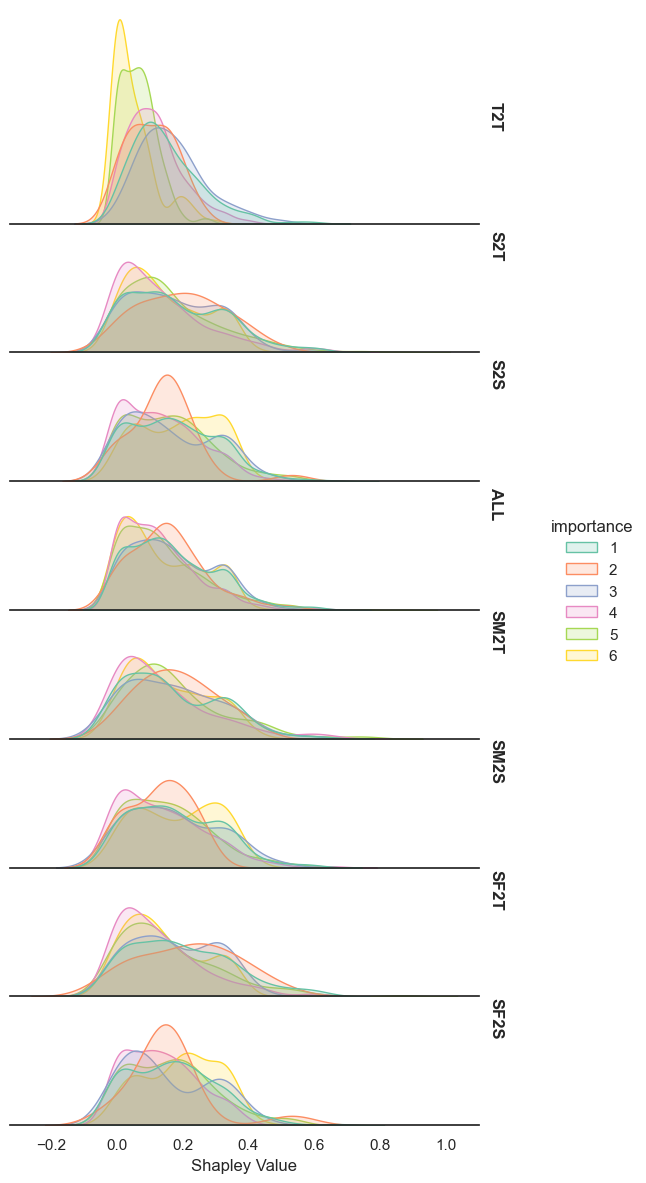

In [28]:
def make_dist_plot(hue_col: str, hspace: float = -0.4) -> sns.displot:
    """Create a distribution plot."""
    g = sns.displot(
        data=all_modes_results_df,
        x=SV_COL,
        hue=hue_col,
        row="mode",
        row_order=full_row_order,
        kind="kde",
        palette="Set2",
        fill=True,
        alpha=0.2,
        aspect=4,
        height=1.5,
        common_norm=False,
        facet_kws={"margin_titles": True},
    )

    g.set_titles(row_template="{row_name}", size=12, fontweight="bold")
    g.set(yticks=[], ylabel="")
    g.despine(left=True)
    g.figure.subplots_adjust(hspace=hspace)
    g.set_axis_labels("Shapley Value", "")


make_dist_plot(hue_col="importance")
plt.savefig("figures/shapley_value_vs_importance_distributions.png")

In [29]:
(all_modes_results_df.groupby("mode").apply(lambda x: x[["importance", SV_COL]].corr().iloc[0, 1])).to_frame(
    name="corr_importance_sv"
)

,corr_importance_sv
mode,
ALL,-0.104559
S2S,-0.010471
S2T,-0.085581
SF2S,0.014297
SF2T,-0.147470
SM2S,-0.034137
SM2T,-0.023837
T2T,-0.360591


Similar analysis for linguistic group.

In [30]:
(
    all_modes_results_df.groupby(["mode", "group"])[SV_COL]
    .agg(["mean", "std"])
    .sort_values(by=["mode", "mean"], ascending=[True, False])
)

mean       std
mode group                                
ALL  core_structure     0.171243  0.133943
     arguments          0.167835  0.125031
     clausal_structure  0.156386  0.115386
     function_words     0.145215  0.135830
     punctuation        0.139492  0.119419
...                          ...       ...
T2T  clausal_structure  0.104454  0.072481
     generic            0.084515  0.079064
     coordination       0.066164  0.048885
     function_words     0.065828  0.054498
     punctuation        0.050541  0.065793

[64 rows x 2 columns]

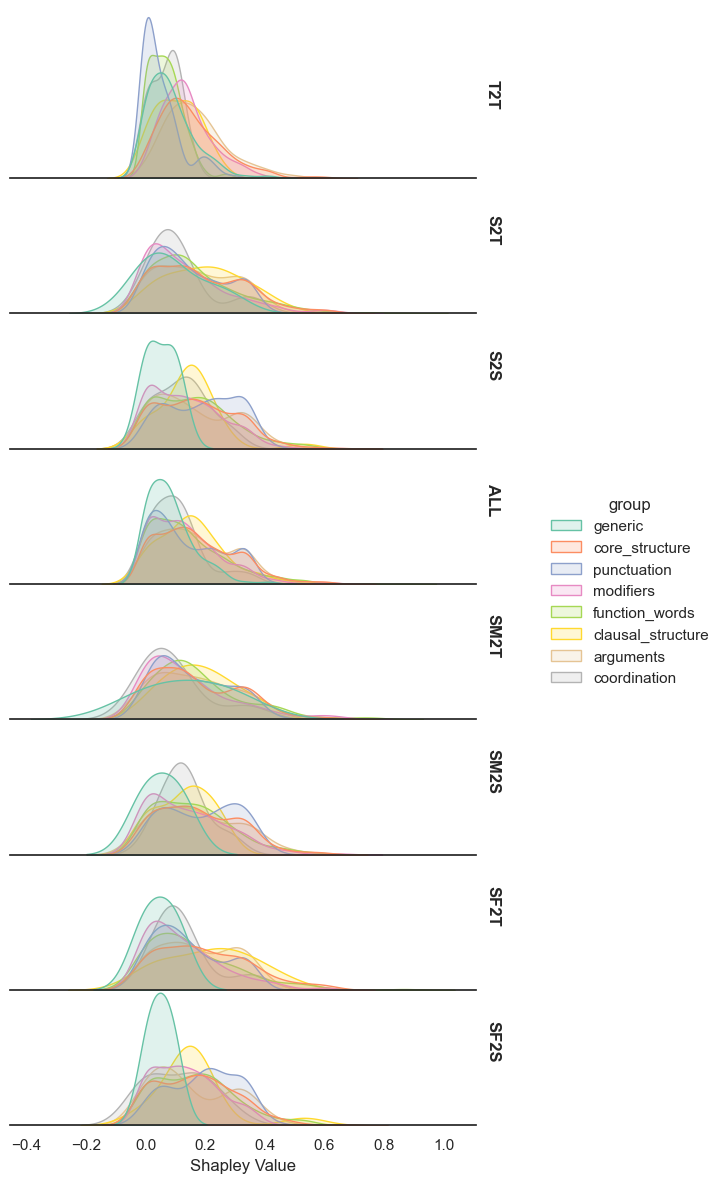

In [31]:
make_dist_plot(hue_col="group", hspace=-0.2)
plt.savefig("figures/shapley_value_vs_group_distributions.png")

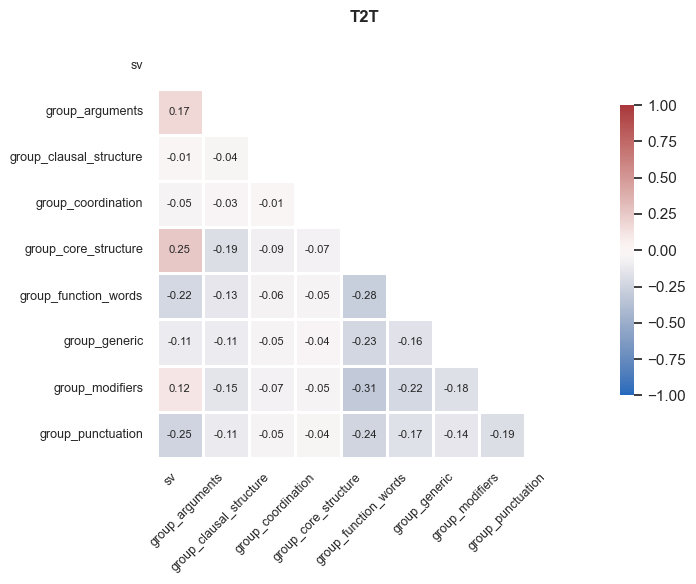

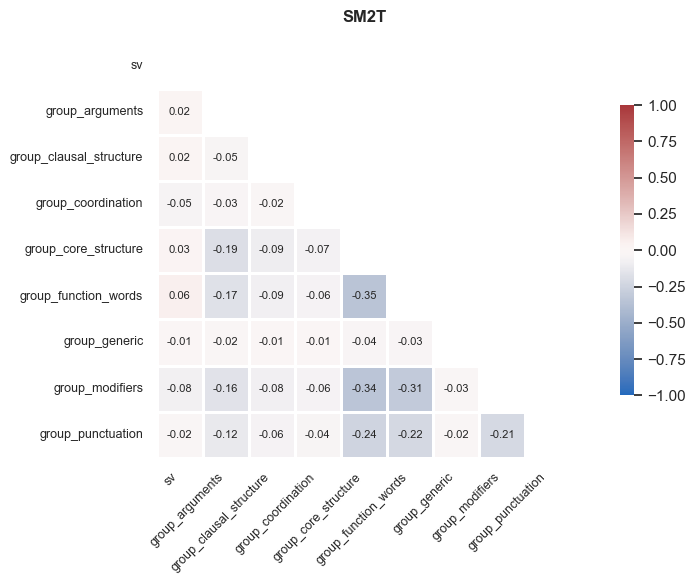

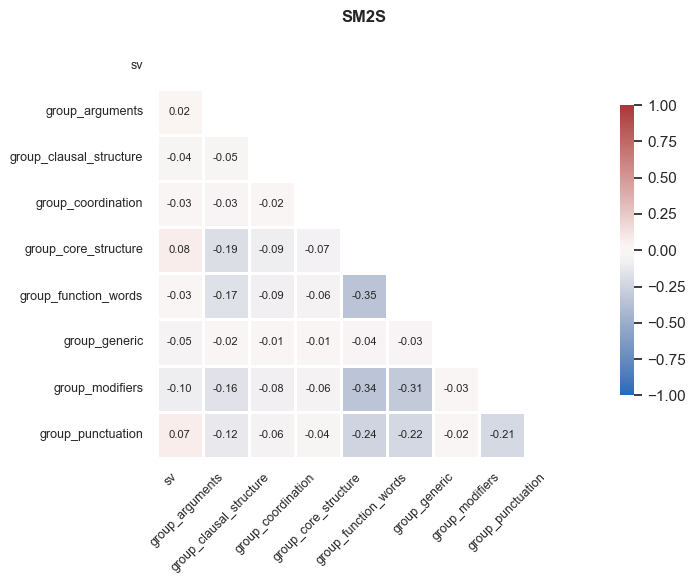

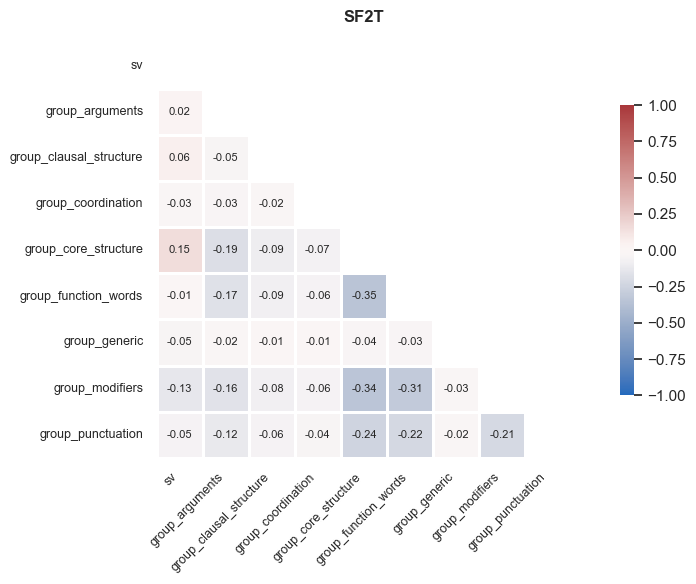

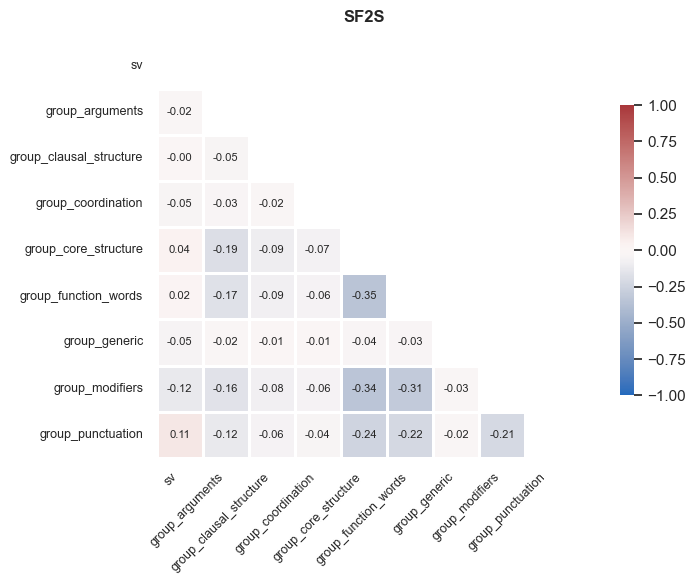

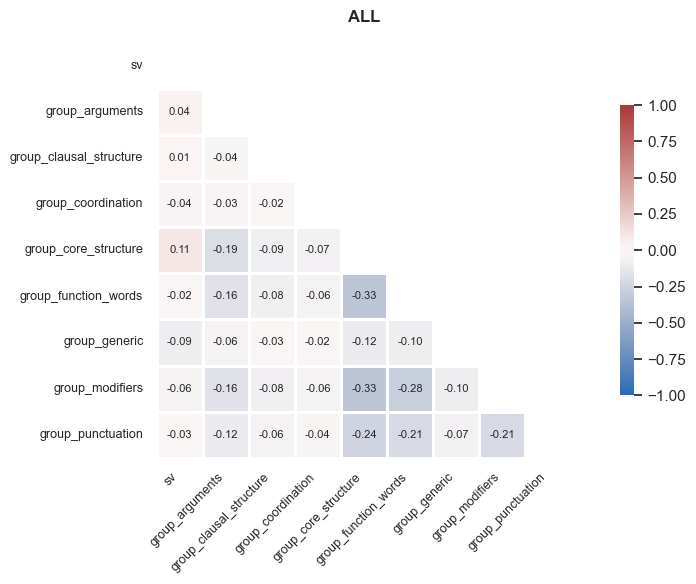

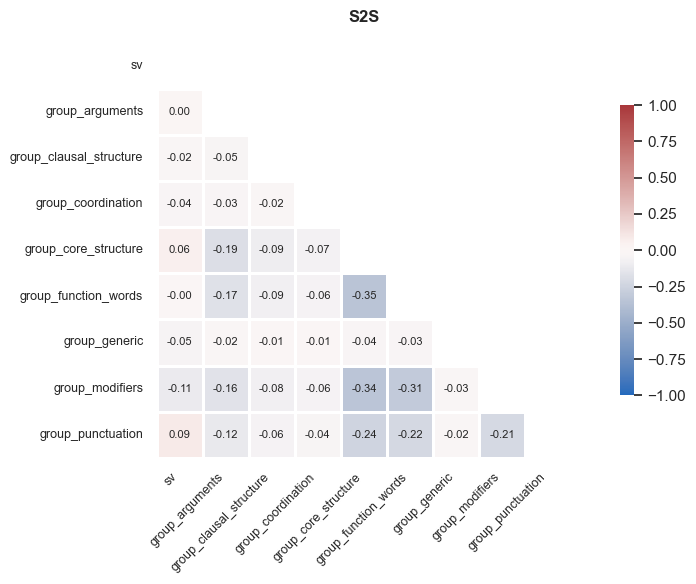

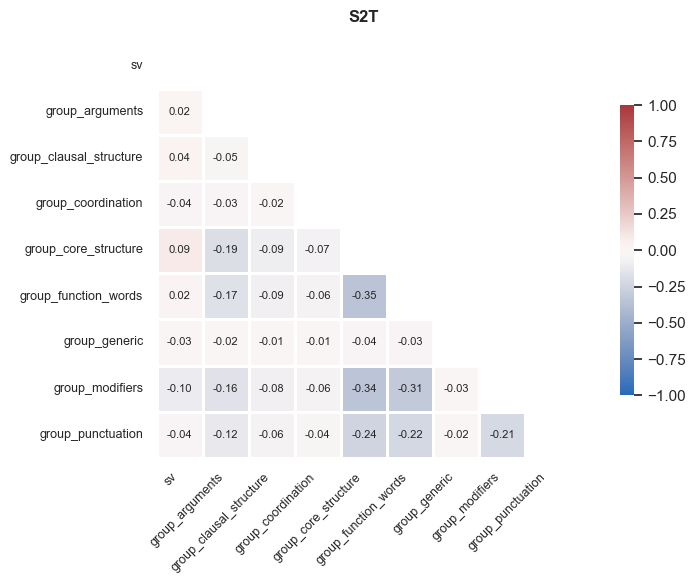

In [32]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoded_df = encoder.fit_transform(all_modes_results_df[["group"]])

full_df = pd.concat([encoded_df, all_modes_results_df[[SV_COL, "mode"]].reset_index(drop=True)], axis=1)

group_cols = list(encoded_df.columns)
cols_to_corr = [SV_COL] + group_cols

for mode in all_modes_results_df["mode"].unique():
    mode_data = full_df[full_df["mode"] == mode][cols_to_corr]
    corr_df = mode_data.corr()

    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.heatmap(
        corr_df,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.8,
        cbar_kws={"shrink": 0.7},
        annot_kws={"size": 8},
        ax=ax,
    )

    ax.set_title(mode, fontsize=12, fontweight="bold", pad=15)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    plt.tight_layout()
    plt.savefig(f"figures/correlation_heatmap_{mode}.png")
    plt.show()

Does the mean values of Shapley values differ significantly between different linguistic groups?

In [33]:
(
    all_modes_results_df[all_modes_results_df["mode"] != "ALL"]
    .groupby(["row_index", "mode"])[SV_COL]
    .mean()
    .unstack(level="mode")
)

mode,S2S,S2T,SF2S,SF2T,SM2S,SM2T,T2T
row_index,,,,,,,
0,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.083333
1,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.111111
2,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.090909
3,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.111111
4,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.111111
...,...,...,...,...,...,...,...
95,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.090909
96,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.090909
97,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.166667


In [34]:
perform_ttest(
    (
        all_modes_results_df[all_modes_results_df["mode"] != "ALL"]
        .groupby(["row_index", "mode"])[SV_COL]
        .mean()
        .unstack(level="mode")
    )
)

T_Statistic       P_Value  Degrees_of_Freedom  Sample_Size  \
Mode_1 Mode_2                                                               
S2S    S2T       -0.240169  8.106959e-01                  99          100   
       SF2T       0.702844  4.838027e-01                  99          100   
       SM2T      -0.998238  3.205976e-01                  99          100   
       T2T       15.551471  2.500122e-28                  99          100   
S2T    SF2S       1.290314  1.999474e-01                  99          100   
       SM2S      -1.100975  2.735771e-01                  99          100   
       T2T       15.551471  2.500121e-28                  99          100   
SF2S   SF2T      -0.463987  6.436756e-01                  99          100   
       SM2S      -1.938011  5.547066e-02                  99          100   
       SM2T      -1.674768  9.713603e-02                  99          100   
       T2T       15.551470  2.500128e-28                  99          100   
SF2T   SM2S      -1.643123  1.035299e-01                  99          100   
       SM2T      -1.375208  1.721712e-01                  99          100   
       T2T       15.551471  2.500123e-28                  99          100   
SM2S   SM2T       0.139204  8.895713e-01                  99          100   
       T2T       15.551471  2.500116e-28                  99          100   
SM2T   T2T       15.551471  2.500119e-28                  99          100   

                  Mean_Diff  Significant_Adj  
Mode_1 Mode_2                                 
S2S    S2T    -1.244027e-10            False  
       SF2T    4.427552e-10            False  
       SM2T   -6.915606e-10            False  
       T2T     6.213203e-02             True  
S2T    SF2S    9.153210e-10            False  
       SM2S   -6.665156e-10            False  
       T2T     6.213203e-02             True  
SF2S   SF2T   -3.481631e-10            False  
       SM2S   -1.581837e-09            False  
       SM2T   -1.482479e-09            False  
       T2T     6.213203e-02             True  
SF2T   SM2S   -1.233673e-09            False  
       SM2T   -1.134316e-09            False  
       T2T     6.213203e-02             True  
SM2S   SM2T    9.935770e-11            False  
       T2T     6.213204e-02             True  
SM2T   T2T     6.213204e-02             True

Does the max values of Shapley values differ significantly between different linguistic groups?

In [35]:
perform_ttest(
    (
        all_modes_results_df[all_modes_results_df["mode"] != "ALL"]
        .groupby(["row_index", "mode"])[SV_COL]
        .max()
        .unstack(level="mode")
    )
)

T_Statistic       P_Value  Degrees_of_Freedom  Sample_Size  \
Mode_1 Mode_2                                                               
S2S    S2T       -4.202630  5.786501e-05                  99          100   
       SF2T      -0.323592  7.469297e-01                  99          100   
       SM2T      -0.374501  7.088327e-01                  99          100   
       T2T        7.814662  5.974419e-12                  99          100   
S2T    SF2S       8.404684  3.235106e-13                  99          100   
       SM2S       6.024282  2.908654e-08                  99          100   
       T2T        9.368035  2.616236e-15                  99          100   
SF2S   SF2T      -4.923210  3.405179e-06                  99          100   
       SM2S      -1.604255  1.118433e-01                  99          100   
       SM2T      -5.120750  1.500741e-06                  99          100   
       T2T        3.947416  1.478818e-04                  99          100   
SF2T   SM2S       2.859786  5.170650e-03                  99          100   
       SM2T      -0.010988  9.912551e-01                  99          100   
       T2T        7.260619  8.864144e-11                  99          100   
SM2S   SM2T      -2.942898  4.050511e-03                  99          100   
       T2T        5.344692  5.811095e-07                  99          100   
SM2T   T2T        7.173547  1.348077e-10                  99          100   

               Mean_Diff  Significant_Adj  
Mode_1 Mode_2                              
S2S    S2T     -0.047096             True  
       SF2T    -0.003717            False  
       SM2T    -0.003858            False  
       T2T      0.098299             True  
S2T    SF2S     0.098476             True  
       SM2S     0.079752             True  
       T2T      0.145396             True  
SF2S   SF2T    -0.055097             True  
       SM2S    -0.018724            False  
       SM2T    -0.055238             True  
       T2T      0.046919             True  
SF2T   SM2S     0.036373            False  
       SM2T    -0.000141            False  
       T2T      0.102016             True  
SM2S   SM2T    -0.036514            False  
       T2T      0.065643             True  
SM2T   T2T      0.102157             True

Let's also have a look on how the cumulative sum curves look like for all samples.

In [36]:
combined_df["sv_cumsum"] = combined_df[SV_COL].apply(np.cumsum)
cumsums = combined_df.groupby("row_index", group_keys=False)[["mode", "row_index", "sv_cumsum"]].apply(
    normalize_lengths
)

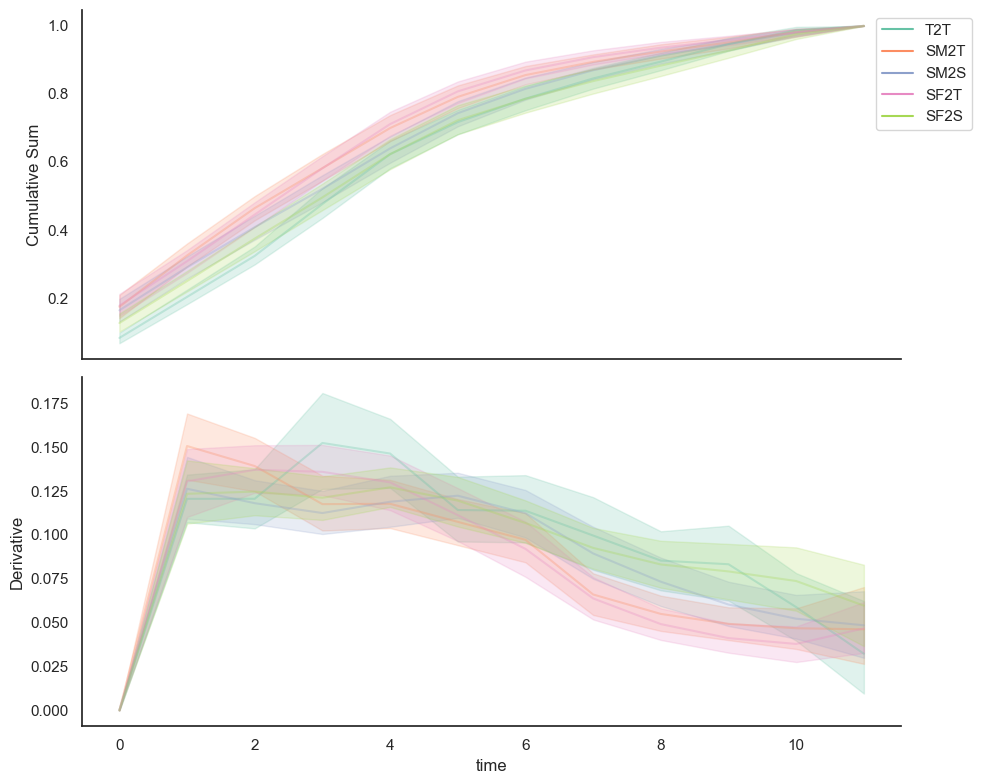

In [37]:
plot_df = cumsums.explode("sv_cumsum").reset_index(drop=True)
plot_df["time"] = plot_df.groupby(["mode", "row_index"]).cumcount()

plot_df["sv_cumsum"] = plot_df["sv_cumsum"].astype(float)
plot_df["sv_derivative"] = plot_df.groupby(["mode", "row_index"])["sv_cumsum"].diff().fillna(0)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

# Top Plot
sns.lineplot(data=plot_df, x="time", y="sv_cumsum", hue="mode", alpha=0.3, legend="brief", ax=ax1, palette="Set2")
ax1.set_ylabel("Cumulative Sum")

# Bottom Plot
sns.lineplot(data=plot_df, x="time", y="sv_derivative", hue="mode", alpha=0.3, legend=False, ax=ax2, palette="Set2")
ax2.set_ylabel("Derivative")

leg = ax1.legend(bbox_to_anchor=(0.96, 1), loc="upper left", frameon=True, facecolor="white")
for lh in leg.legend_handles:
    lh.set_alpha(1)

sns.despine()
plt.tight_layout()
plt.savefig("figures/cumulative_shapley_and_derivative.png")
plt.show()